In [ ]:
import pandas as pd
import os
import numpy as np

from pathlib import Path
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.optim.lr_scheduler import StepLR
from scipy.signal import correlate
from torch.utils.data import TensorDataset, DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error 

1) Реализовать загрузку/очистку/обработку данных (как на паре)
2) Написать класс модели полносвязной нейронной сети (задача регрессии)
3) Запустить цикл обучения. В качестве loss-function взять:
- MSE
- MAE
4) Построить графики ошибок от эпохи обучения


In [3]:
data = {}

p = Path(os.getcwd()) / 'data' 
for x in p.rglob("*.csv"):
    data[x.stem] = pd.read_csv(x)


In [4]:
close = pd.concat(data).loc['close_in_sample']

In [5]:
close.index = pd.to_datetime(close['openTime'])

In [6]:
close = close.drop(columns=['Unnamed: 0', 'openTime'])

In [7]:
returns = close.pct_change().shift(-1)

In [8]:
y = returns

In [ ]:
pd.concat(data, axis=1)

bvolume_in_sample                                                    \
             Unnamed: 0                   openTime 1000SATSUSDT 1INCHUSDT   
0                 17170  2021-08-24 03:00:00+00:00          NaN  1.958014   
1                 17171  2021-08-24 04:00:00+00:00          NaN -0.441804   
2                 17172  2021-08-24 05:00:00+00:00          NaN -0.218468   
3                 17173  2021-08-24 06:00:00+00:00          NaN  0.825881   
4                 17174  2021-08-24 07:00:00+00:00          NaN -0.429266   
...                 ...                        ...          ...       ...   
17364             34534  2023-08-17 15:00:00+00:00          NaN -0.341552   
17365             34535  2023-08-17 16:00:00+00:00          NaN -0.801493   
17366             34536  2023-08-17 17:00:00+00:00          NaN -0.181284   
17367             34537  2023-08-17 18:00:00+00:00          NaN -0.247830   
17368             34538  2023-08-17 19:00:00+00:00          NaN       NaN   

                                                                ...  \
       AAVEUSDT ACEUSDT   ACHUSDT   ADAUSDT AEVOUSDT  AGIXUSDT  ...   
0      0.164404     NaN       NaN  0.305252      NaN       NaN  ...   
1     -0.322729     NaN       NaN -0.306240      NaN       NaN  ...   
2      0.302341     NaN       NaN  0.721942      NaN       NaN  ...   
3      0.168517     NaN       NaN -0.260580      NaN       NaN  ...   
4     -0.467516     NaN       NaN -0.101271      NaN       NaN  ...   
...         ...     ...       ...       ...      ...       ...  ...   
17364 -0.263612     NaN -0.089095 -0.322264      NaN -0.122860  ...   
17365 -0.738242     NaN -0.820401 -0.739573      NaN -0.686261  ...   
17366 -0.207137     NaN -0.133797  0.481462      NaN -0.381288  ...   
17367 -0.318899     NaN -0.117698 -0.588892      NaN -0.269362  ...   
17368       NaN     NaN       NaN       NaN      NaN       NaN  ...   

      ntrades_in_sample                                                      \
                XRPUSDT  XTZUSDT  XVGUSDT XVSUSDT  YFIUSDT  YGGUSDT ZECUSDT   
0               45133.0   8346.0      NaN     NaN   5146.0      NaN  6461.0   
1               50707.0  34227.0      NaN     NaN   4283.0      NaN  6424.0   
2               37030.0  45323.0      NaN     NaN   3845.0      NaN  4844.0   
3               46376.0  20187.0      NaN     NaN   3521.0      NaN  6182.0   
4               68646.0  14749.0      NaN     NaN   3488.0      NaN  4853.0   
...                 ...      ...      ...     ...      ...      ...     ...   
17364          132285.0   8513.0  25362.0  4405.0  13340.0  22563.0  6706.0   
17365          109991.0   5621.0  11879.0  4278.0  11894.0  16937.0  5543.0   
17366           60610.0   1880.0   5883.0  3118.0   4598.0   5602.0  2720.0   
17367           26875.0   1226.0   4874.0  2230.0   4027.0   6402.0  2430.0   
17368           17803.0   1514.0   5111.0  1783.0   3266.0   4294.0  1895.0   

                                  
       ZENUSDT  ZILUSDT  ZRXUSDT  
0       5015.0   9387.0   7039.0  
1       5507.0   7731.0   6313.0  
2       5902.0   9005.0   6901.0  
3       6580.0   7262.0   7497.0  
4       5062.0   9699.0   5675.0  
...        ...      ...      ...  
17364   9790.0  14570.0  10258.0  
17365  10696.0  11640.0   8634.0  
17366   4202.0   4248.0   3095.0  
17367   3827.0   2291.0   2701.0  
17368   2960.0   2582.0   1461.0  

[17369 rows x 1944 columns]

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

In [11]:
training_data = pd.read_csv('full_data.csv', index_col = 'openTime')


In [12]:
train_columns = []
test_columns = []

for col in training_data.columns:
    if "_ret" in col:
        test_columns.append(col)
    else:
        train_columns.append(col)

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [14]:
window_size = 100

all_x = np.lib.stride_tricks.sliding_window_view(training_data.values, (window_size, training_data.shape[1]))[:, 0]
all_y = training_data[test_columns].iloc[99:]

In [15]:
training_data.shape

(7551, 630)

In [16]:
all_x.shape, all_y.shape

((7452, 100, 630), (7452, 63))

In [17]:
x_test = all_x[-850:].view()
y_test = all_y[-850:].values.view()

In [18]:
x = all_x[:-(850 + 120)].view()
y = all_y[:-(850 + 120)].values.view()

In [19]:
val_len = 1000

In [20]:
val_start = x.shape[0] // 2 - val_len // 2
val_end = val_start + val_len

In [21]:
x_val = x[val_start: val_end]
y_val = y[val_start: val_end]

In [22]:
x_val.shape, y_val.shape

((1000, 100, 630), (1000, 63))

In [23]:
x_train = np.concatenate((x[:val_start - 100], x[val_end + 100:]))
y_train = np.concatenate((y[:val_start - 100], y[val_end + 100:]))

In [24]:
x_train.shape, x_val.shape, x_test.shape

((5282, 100, 630), (1000, 100, 630), (850, 100, 630))

In [25]:
y_train.shape, y_val.shape, y_test.shape

((5282, 63), (1000, 63), (850, 63))

### Tensors


In [26]:
x_train = torch.Tensor(x_train)
x_train = np.where(np.isinf(x_train), np.nan, x_train)
x_train = np.where(np.isnan(x_train), np.nanmean(x_train, axis=0), x_train)
x_train = torch.Tensor(x_train)

y_train = torch.Tensor(y_train)
y_train = np.where(np.isinf(y_train), np.nan, y_train)
y_train = np.where(np.isnan(y_train), np.nanmean(y_train, axis=0), y_train)
y_train = torch.Tensor(y_train)

x_val = torch.Tensor(x_val)
x_val = np.where(np.isinf(x_val), np.nan, x_val)
x_val = np.where(np.isnan(x_val), np.nanmean(x_val, axis=0), x_val)
x_val = torch.Tensor(x_val)

y_val = torch.Tensor(y_val)
y_val = np.where(np.isinf(y_val), np.nan, y_val)
y_val = np.where(np.isnan(y_val), np.nanmean(y_val, axis=0), y_val)
y_val = torch.Tensor(y_val)

x_test = torch.Tensor(x_test)
x_test = np.where(np.isinf(x_test), np.nan, x_test)
x_test = np.where(np.isnan(x_test), np.nanmean(x_test, axis=0), x_test)
x_test = torch.Tensor(x_test)

y_test = torch.Tensor(y_test)
y_test = np.where(np.isinf(y_test), np.nan, y_test)
y_test = np.where(np.isnan(y_test), np.nanmean(y_test, axis=0), y_test)
y_test = torch.Tensor(y_test)

### Models

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.activation = nn.ReLU() 
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out)
        out = self.activation(out)

        return out



In [ ]:


class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        # Убираем ReLU — он ломает отрицательные доходности!
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out[:, -1, :])
        return out

### Learning

In [ ]:

input_size = x_train.shape[2]
output_size = y_train.shape[1]
hidden_size = 63 

model = LSTMModel(input_size, hidden_size, output_size)

In [33]:
criterion_mse = nn.MSELoss()
criterion_mae = nn.L1Loss() 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [30]:
print("x_train.shape:", x_train.shape)  # (5282, 100, 630)
print("y_train.shape:", y_train.shape)  # например, (5282, 63)

x_train.shape: torch.Size([5282, 100, 630])
y_train.shape: torch.Size([5282, 63])


In [35]:
history = {
    'train_mse': [], 'val_mse': [],
    'train_mae': [], 'val_mae': []
}


In [36]:

train_dataset = TensorDataset(x_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

num_epochs = 30
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
x_val, y_val = x_val.to(device), y_val.to(device)

#MSE - оптимизация, MAE - метрика
for epoch in range(num_epochs):
    model.train()
    epoch_train_mse = 0.0
    epoch_train_mae = 0.0
    num_batches = 0
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x)

        loss = criterion_mse(outputs, batch_y)
        loss.backward()
        optimizer.step()

        mae = criterion_mae(outputs, batch_y)
        
        epoch_train_mse += loss.item()
        epoch_train_mae += mae.item()
        num_batches += 1

    avg_train_mse = epoch_train_mse / num_batches
    avg_train_mae = epoch_train_mae / num_batches
    
    # Валидация
    model.eval()
    with torch.no_grad():
        val_pred = model(x_val)
        val_mse = criterion_mse(val_pred, y_val).item()
        val_mae = criterion_mae(val_pred, y_val).item()
    
    history['train_mse'].append(avg_train_mse)
    history['val_mse'].append(val_mse)
    history['train_mae'].append(avg_train_mae)
    history['val_mae'].append(val_mae)
    
    print(f"Epoch {epoch+1:02d} | Train MSE: {avg_train_mse:.6f} | Val MSE: {val_mse:.6f} | Val MAE: {val_mae:.6f}")

Epoch 01 | Train MSE: 0.000139 | Val MSE: 0.000155 | Val MAE: 0.008364
Epoch 02 | Train MSE: 0.000141 | Val MSE: 0.000153 | Val MAE: 0.008406
Epoch 03 | Train MSE: 0.000134 | Val MSE: 0.000146 | Val MAE: 0.008191
Epoch 04 | Train MSE: 0.000127 | Val MSE: 0.000141 | Val MAE: 0.007992
Epoch 05 | Train MSE: 0.000119 | Val MSE: 0.000131 | Val MAE: 0.007720
Epoch 06 | Train MSE: 0.000115 | Val MSE: 0.000132 | Val MAE: 0.007820
Epoch 07 | Train MSE: 0.000114 | Val MSE: 0.000126 | Val MAE: 0.007582
Epoch 08 | Train MSE: 0.000106 | Val MSE: 0.000121 | Val MAE: 0.007476
Epoch 09 | Train MSE: 0.000104 | Val MSE: 0.000130 | Val MAE: 0.007863
Epoch 10 | Train MSE: 0.000109 | Val MSE: 0.000123 | Val MAE: 0.007532
Epoch 11 | Train MSE: 0.000101 | Val MSE: 0.000110 | Val MAE: 0.007120
Epoch 12 | Train MSE: 0.000095 | Val MSE: 0.000118 | Val MAE: 0.007485
Epoch 13 | Train MSE: 0.000092 | Val MSE: 0.000107 | Val MAE: 0.007056
Epoch 14 | Train MSE: 0.000088 | Val MSE: 0.000100 | Val MAE: 0.006789
Epoch 

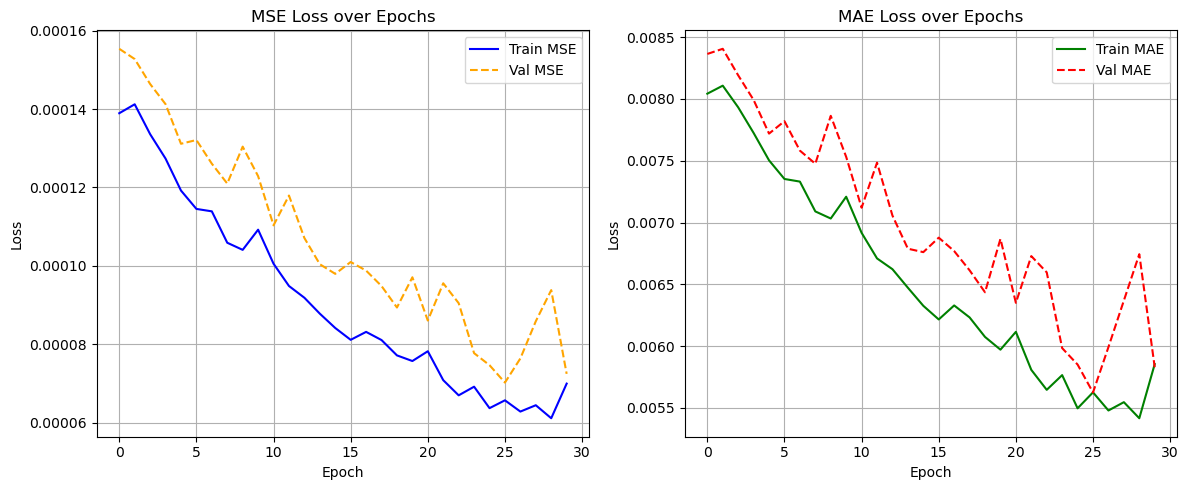

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_mse'], label='Train MSE', color='blue')
plt.plot(history['val_mse'], label='Val MSE', color='orange', linestyle='--')
plt.title('MSE Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['train_mae'], label='Train MAE', color='green')
plt.plot(history['val_mae'], label='Val MAE', color='red', linestyle='--')
plt.title('MAE Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


### Saving of model

In [42]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'hidden_size': hidden_size,
    'input_size': input_size,
    'output_size': output_size,
}, 'lstm_model_full.pth')

print("Модель сохранена!")

# model = LSTMModel(input_size, hidden_size, output_size)
# model.load_state_dict(torch.load('lstm_model.pth'))
# model.eval()


Модель сохранена!


### Test of model


MSE: 0.000006 | MAE: 0.001301 | Corr: 0.9874
Return: 279016.97% | Sharpe: 13.66 | MaxDD: -2.21% | WinRate: 90.24%


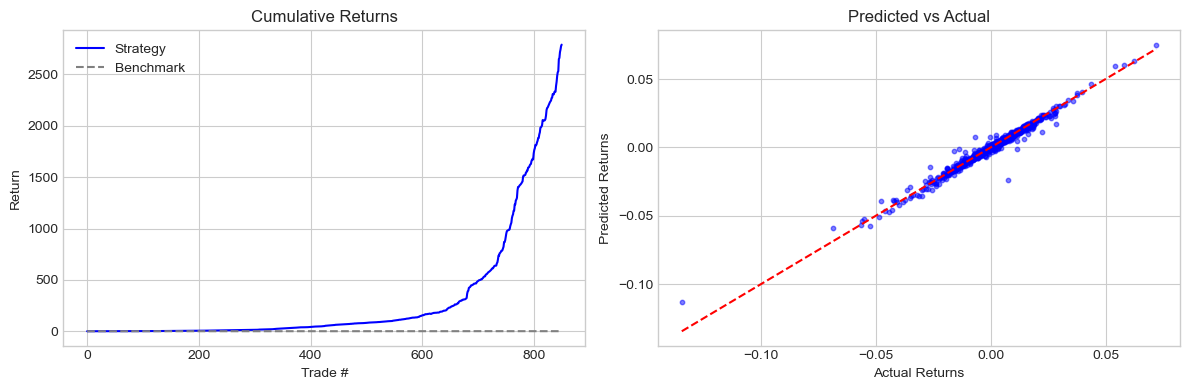

✓ Saved: backtest.png, backtest_results.csv, backtest_metrics.csv


In [ ]:
def preprocess_data(data):
    data = np.array(data, dtype=np.float32)
    data = np.where(np.isinf(data), np.nan, data)
    col_means = np.nanmean(data, axis=0, keepdims=True)
    return torch.FloatTensor(np.where(np.isnan(data), col_means, data))

x_test = preprocess_data(x_test).to('cuda' if torch.cuda.is_available() else 'cpu')
y_test = preprocess_data(y_test).cpu().numpy()

model = LSTMModel(630, 63, 63)
model.load_state_dict(torch.load('lstm_model.pth', map_location='cpu'))
model.eval()
model.to(x_test.device)

with torch.no_grad():
    predictions = model(x_test).cpu().numpy()
    y_true = y_test

pred_returns = predictions.mean(axis=1)
true_returns = y_true.mean(axis=1)

signals = np.zeros_like(pred_returns)
signals[pred_returns > 0] = 1
signals[pred_returns < 0] = -1

def backtest(signals, returns, cost=0.001):
    n = len(signals)
    port_vals, strat_rets = [1.0], []
    
    for i in range(n):
        ret = signals[i] * returns[i]
        if i > 0:
            ret -= abs(signals[i] - signals[i-1]) * cost
        strat_rets.append(ret)
        port_vals.append(port_vals[-1] * (1 + ret))
    
    port_vals = np.array(port_vals[1:])
    strat_rets = np.array(strat_rets)
    bench = np.cumprod(1 + returns) - 1
    
    sharpe = np.mean(strat_rets) / np.std(strat_rets) * np.sqrt(252) if np.std(strat_rets) > 0 else 0
    max_dd = np.min((port_vals - np.maximum.accumulate(port_vals)) / np.maximum.accumulate(port_vals))
    
    return {
        'cum_ret': port_vals - 1, 'bench': bench, 'strat_rets': strat_rets,
        'signals': signals, 'total_ret': port_vals[-1] - 1,
        'sharpe': sharpe, 'max_dd': max_dd,
        'win_rate': np.mean(strat_rets > 0), 'n_trades': np.sum(np.abs(np.diff(signals)) > 0)
    }

results = backtest(signals, true_returns)

mse = mean_squared_error(true_returns, pred_returns)
mae = mean_absolute_error(true_returns, pred_returns)
corr = np.corrcoef(true_returns, pred_returns)[0, 1]

print(f"\nMSE: {mse:.6f} | MAE: {mae:.6f} | Corr: {corr:.4f}")
print(f"Return: {results['total_ret']*100:.2f}% | Sharpe: {results['sharpe']:.2f} | MaxDD: {results['max_dd']*100:.2f}% | WinRate: {results['win_rate']*100:.2f}%")


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(results['cum_ret'], label='Strategy', color='blue')
plt.plot(results['bench'], label='Benchmark', color='gray', linestyle='--')
plt.title('Cumulative Returns')
plt.xlabel('Trade #')
plt.ylabel('Return')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(true_returns, pred_returns, alpha=0.5, s=10, color='blue')
plt.plot([true_returns.min(), true_returns.max()], [true_returns.min(), true_returns.max()], 'r--')
plt.title('Predicted vs Actual')
plt.xlabel('Actual Returns')
plt.ylabel('Predicted Returns')
plt.grid(True)

plt.tight_layout()
plt.savefig('backtest.png', dpi=300, bbox_inches='tight')
plt.show()


pd.DataFrame({
    'cumulative_returns': results['cum_ret'],
    'benchmark': results['bench'],
    'strategy_returns': results['strat_rets'],
    'signals': results['signals']
}).to_csv('backtest_results.csv', index=False)

pd.DataFrame([{
    'mse': mse, 'mae': mae, 'correlation': corr,
    'total_return': results['total_ret'], 'sharpe': results['sharpe'],
    'max_drawdown': results['max_dd'], 'win_rate': results['win_rate'],
    'n_trades': results['n_trades']
}]).to_csv('backtest_metrics.csv', index=False)

print("Saved")